### Necessary Imports

In [ ]:
from astropy.table import Table, QTable
import astropy.units as u
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib
import requests

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

### Now let's read in all our good CNN predicted periods

In [3]:
reportable = pd.read_csv('reportable.csv', index_col='Unnamed: 0').rename(columns={'edr3_source_id':'EDR3', 'dr2_source_id':'gaia_id'})
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5
reportable['frac'] = reportable['sigma']/reportable['period']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### And divide them into their subpopulations

In [4]:
cold = reportable[reportable['bp-rp'] >= 0.6]
hot = reportable[reportable['bp-rp'] < 0.6]

oscillators = cold[cold['abs_g_mag'] <= ((2*cold['bp-rp']) - 4)]
nonoscillators = cold[cold['abs_g_mag'] > ((2*cold['bp-rp']) - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < ((1.4*nonoscillators['bp-rp'])+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= ((1.4*nonoscillators['bp-rp'])+2.8)]

In [5]:
astropy_oscillators = QTable().from_pandas(oscillators)
astropy_oscillators = astropy_oscillators.filled(np.nan) 
astropy_oscillators['period'] = astropy_oscillators['period'] * u.day
astropy_oscillators['g_star'] = 10**(astropy_oscillators['logg_xgboost'])
astropy_oscillators['teff_xgboost'] =  astropy_oscillators['teff_xgboost']*u.Kelvin

sol_g = 10**(4.438)
sol_teff = 5772*u.Kelvin
sol_muhz = 3076*u.uHz

astropy_oscillators['nu'] = (((astropy_oscillators['g_star']/sol_g) * (astropy_oscillators['teff_xgboost']/sol_teff)**(-0.5))*sol_muhz).to(u.d**(-1))
astropy_oscillators['day'] = 1/astropy_oscillators['nu']
oscillators_final = astropy_oscillators.to_pandas()
# all the above is identical to the Figure 15 file. Now we also add in the APOKASC information

In [6]:
apokascurl = 'https://content.cld.iop.org/journals/0067-0049/276/2/69/revision1/apjsad9feft4_mrt.txt'
query_parameters = {"downloadformat": "txt"}
response = requests.get(apokascurl, params=query_parameters)
with open("apokasc.txt", mode="wb") as file:
    file.write(response.content)
apokasc = Table.read("apokasc.txt", format="ascii.cds").to_pandas()

In [7]:
mergedus_apokasc = pd.merge(apokasc, oscillators_final, on='KIC', how='inner')
oscillators_good = mergedus_apokasc[mergedus_apokasc['period'] >= mergedus_apokasc['day']]
oscillators_bad = mergedus_apokasc[mergedus_apokasc['period'] < mergedus_apokasc['day']]

above11 = QTable.from_pandas(oscillators_good)
above11['apokasc_dG']  = 1/(above11['Numax']*u.uHz.to(u.d**(-1)))
findg = above11.to_pandas()

below11 = QTable.from_pandas(oscillators_bad)
below11['apokasc_dB']  = 1/(below11['Numax']*u.uHz.to(u.d**(-1)))
findb = below11.to_pandas()

diffG = (np.abs((findg['apokasc_dG'] - findg['day']))/findg['apokasc_dG']).dropna()
diffG = diffG[diffG!=0]
diffB = (np.abs((findb['apokasc_dB'] - findb['day']))/findb['apokasc_dB']).dropna()
diffB = diffB[diffB!=0]

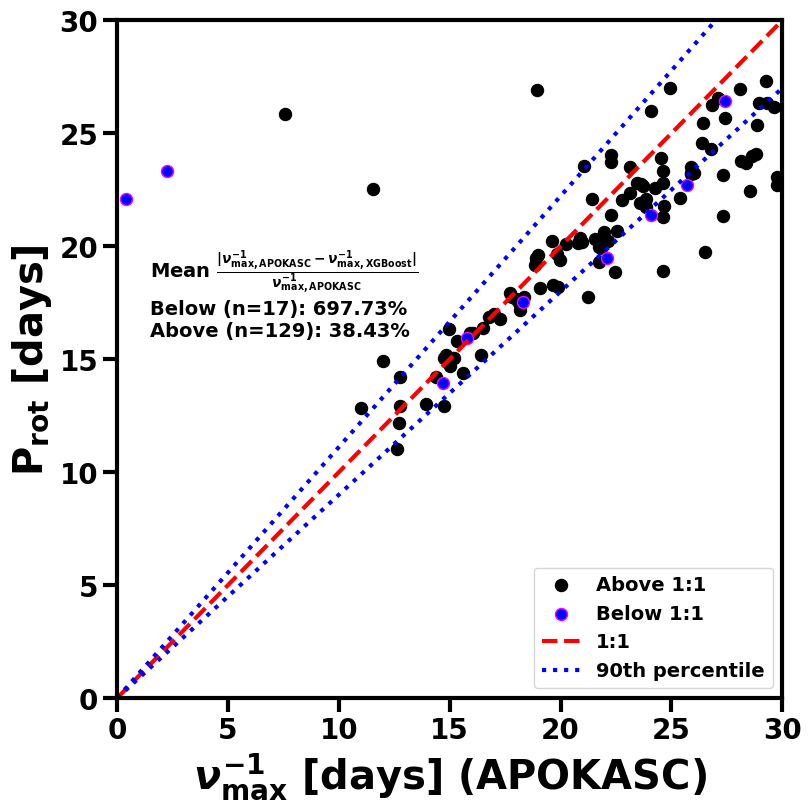

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(8, 8), layout='constrained')
im = axs.scatter(findg['apokasc_dG'], findg['period'], c='k', s=75, rasterized=True, label='Above 1:1')
im = axs.scatter(findb['apokasc_dB'], findb['period'], c='blue', edgecolors= "magenta", s=75, rasterized=True, label='Below 1:1')

axs.plot([0, 30], [0, 30], "r--", label="1:1", linewidth=3, rasterized=True)
axs.plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", linewidth=3, rasterized=True)
axs.plot([0, 30], [0, 30*0.9], "b:", linewidth=3, rasterized=True)
axs.set(xlim=[0, 30], ylim=[0, 30], xlabel=r'$\nu_{\rm{max}}^{-1}$ [days] (APOKASC)',  ylabel=r'P$_{\rm{rot}}$ [days]')
axs.legend(loc='lower right', fontsize=14)
axs.text(1.5, 16, r'Mean $\frac{|\nu_{\rm{max, APOKASC}}^{-1} - \nu_{\rm{max, XGBoost}}^{-1} | }{\nu_{\rm{max, APOKASC}}^{-1}}$' + '\nBelow (n=' + str(len(diffB))+ '): ' + str("%.2f" % (np.mean(diffB)*100)) + '%\nAbove (n='+str(len(diffG))+ '): '  + str("%.2f" % (np.mean(diffG)*100))+"%", fontsize=14)
plt.show()